here we import the csv file for the project, the one we downloadef from kaggle.

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('fake_job_postings.csv')
df.shape

(17880, 18)

here we need to get the overview of the dataset

In [100]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

here we need to check the missing values after we have seen the overview of the data

In [101]:
df.isnull().sum()


,0
job_id,0
title,0
location,346
department,11547
salary_range,15012
company_profile,3308
description,1
requirements,2696
benefits,7212
telecommuting,0


here confirm the actual class distribution of my target variable directly from the data, not from the Kaggle dataset description. so am looking to verify the imbalance that i said in my project proposal (17,014 vs 866, ~4.8% fraudulent)

In [102]:
df['fraudulent'].value_counts()


,count
fraudulent,
0,17014
1,866


here we do duplicate check

In [103]:
df.duplicated().sum()


np.int64(0)

here we check the Missing description row

In [104]:
df[df['description'].isnull()]


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
17513,17514,Office Manager,"PL, MZ, Warsaw",NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,NaN,1


here to confirm the label for that specific row so i can know whether dropping it removes a rare fraud example (bad, since minority class is already scarce) or a legitimate one (less costly to drop).

In [105]:
df.loc[17513, 'fraudulent']

np.int64(1)

Another EDA , here we check whether company_profile and benefits are missing more often in fraudulent postings than legitimate ones, if scammers skip these fields at a higher rate, that's a second,independent piece of evidence supporting the same "thin content" pattern and something you could even consider encoding as a feature later although have chosen text-only,so it'd stay as a discussion point but not a model input.

In [106]:
df.groupby('fraudulent')[['company_profile', 'benefits']].apply(lambda x: x.isnull().mean())

,company_profile,benefits
fraudulent,,
0,0.159927,0.402492
1,0.677829,0.420323


here we combining all text fields into one, then comparing the length of that combined text between fraudulent and legitimate postings checking whether fraud postings tend to be noticeably shorter or thinner on detail.

In [107]:
text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']
df[text_cols] = df[text_cols].fillna('')
df['full_text'] = df[text_cols].agg(' '.join, axis=1)
df['text_length'] = df['full_text'].str.len()

df.groupby('fraudulent')['text_length'].describe()

,count,mean,std,min,25%,50%,75%,max
fraudulent,,,,,,,,
0,17014.0,2700.587575,1455.796410,83.0,1639.00,2560.5,3497.75,14945.0
1,866.0,2078.638568,1529.723943,18.0,949.25,1656.5,2874.50,9752.0


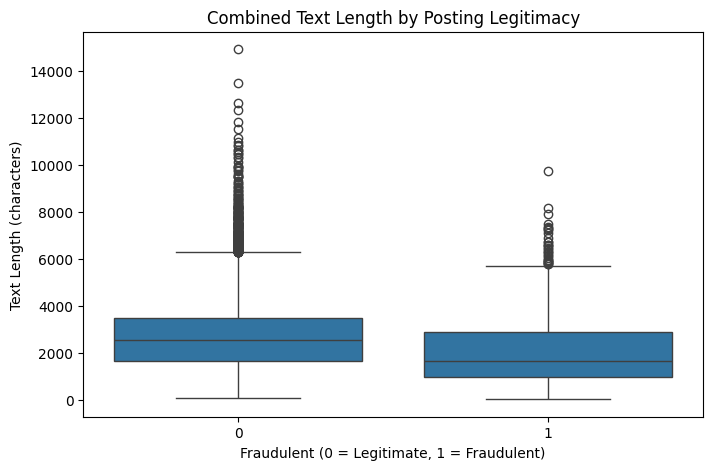

In [108]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='fraudulent', y='text_length', data=df)
plt.title('Combined Text Length by Posting Legitimacy')
plt.xlabel('Fraudulent (0 = Legitimate, 1 = Fraudulent)')
plt.ylabel('Text Length (characters)')
plt.show()


#Step 3

Text preprocessing:Building a cleaning function applied to the combined text field lowercasing,replacing redacted URL placeholders with a token by preserving the signal that a link was present rather than deleting it, and stripping HTML tags and normalising whitespace/punctuation.
but deliberately not removing stopwords or lemmatising yet that will be tested as a separate comparison later ,per the proposal's note to avoid excessive cleaning without justification.

In [109]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'#url_\w+#', ' urltoken ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['full_text'].apply(clean_text)

here we check if the cleaning function worked as expected by comparing a raw vs cleaned example before applying it dataset-wide

In [110]:
print("BEFORE:\n", df['full_text'].iloc[0][:300])
print("\nAFTER:\n", df['clean_text'].iloc[0][:300])

BEFORE:
 Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and 

AFTER:
 marketing intern we re food52 and we ve created a groundbreaking and award winning cooking site we support connect and celebrate home cooks and give them everything they need in one place we have a top editorial business and engineering team we re focused on using technology to find new and better w


Here we rechecking text length on the cleaned column to confirm cleaning didn't drastically shrink or destroy content.

In [111]:
df['clean_length'] = df['clean_text'].str.len()
df.groupby('fraudulent')['clean_length'].describe()

,count,mean,std,min,25%,50%,75%,max
fraudulent,,,,,,,,
0,17014.0,2589.671094,1408.518745,78.0,1577.0,2464.0,3376.00,14599.0
1,866.0,1987.780600,1474.931215,14.0,910.0,1594.0,2761.25,9406.0


#Step 4:

Splitting into train/test before vectorisation, using stratify to preserve the ~4.8% fraud ratio in both sets. we splitting first rather than vectorising the whole dataset then splitting after, to avoids the TF-IDF vocabulary being influenced by test-set text it shouldn't have seen.


In [112]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['fraudulent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [113]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

fraudulent
0    0.951552
1    0.048448
Name: proportion, dtype: float64
fraudulent
0    0.951622
1    0.048378
Name: proportion, dtype: float64


Vectorising with TF-IDF fit only on X_train. and limiting to the top 5000 terms (max_features) keeps the feature space manageable given the dataset size and class imbalance, including both unigrams and bigrams (ngram_range) since two-word phrases (example like 'wire transfer', 'no experience') can carry fraud signal that single words miss, and requiring a term to appear in at least 5 documents (min_df) filters out rare noise/typos that would otherwise bloat the vocabulary.

In [114]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape, X_test_tfidf.shape)

(14304, 5000) (3576, 5000)


#Step 5

We training three classifiers on the TF-IDF features Logistic Regression and Linear SVM with class_weight='balanced' to address the imbalance, and Multinomial Naive Bayes as a baseline but it doesn't support class weighting, so it shows what performance looks like without any imbalance handling.

In [115]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC


In [116]:
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [117]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

svm = LinearSVC(class_weight='balanced', random_state=42)
svm.fit(X_train_tfidf, y_train)

print("All three models trained.")

All three models trained.


now we are evaluating each model on the heldout test set using precision, recall and F1 with particular attention to the fraudulent class, since accuracy alone would be misleading given the imbalance."

In [118]:
from sklearn.metrics import classification_report
models = {'Logistic Regression': log_reg, 'Naive Bayes': nb, 'Linear SVM': svm}

for name, model in models.items():
    preds = model.predict(X_test_tfidf)
    print(f"--- {name} ---")
    print(classification_report(y_test, preds, target_names=['Legitimate', 'Fraudulent']))

--- Logistic Regression ---
              precision    recall  f1-score   support

  Legitimate       0.99      0.97      0.98      3403
  Fraudulent       0.60      0.90      0.72       173

    accuracy                           0.97      3576
   macro avg       0.80      0.94      0.85      3576
weighted avg       0.98      0.97      0.97      3576

--- Naive Bayes ---
              precision    recall  f1-score   support

  Legitimate       0.97      1.00      0.98      3403
  Fraudulent       0.97      0.41      0.58       173

    accuracy                           0.97      3576
   macro avg       0.97      0.70      0.78      3576
weighted avg       0.97      0.97      0.97      3576

--- Linear SVM ---
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      3403
  Fraudulent       0.79      0.87      0.83       173

    accuracy                           0.98      3576
   macro avg       0.89      0.93      0.91      3576
weighte

#Step 6

Here we do visualising confusion matrices for all three models to show the actual counts behind the precision/recall numbers , how many fraudulent postings each model catches vs misses, and how many legitimate postings get incorrectly flagged."

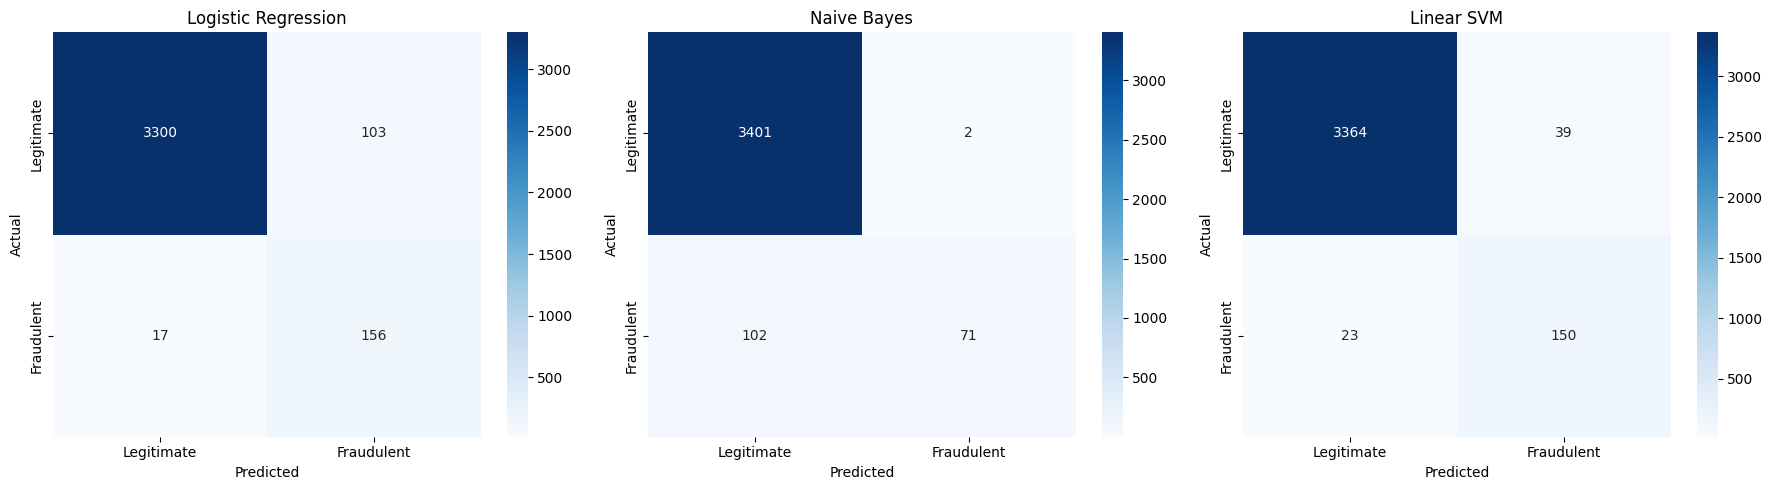

In [119]:
from sklearn.metrics import confusion_matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    preds = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legitimate', 'Fraudulent'],
                yticklabels=['Legitimate', 'Fraudulent'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

Now since Linear SVM gave the best balance of precision and recall tuning its decision threshold next LinearSVC doesn't output probabilities but decision_function gives a raw score we can use the same way by moving the cutoff to trade recall against precision depending on what the business prioritises."

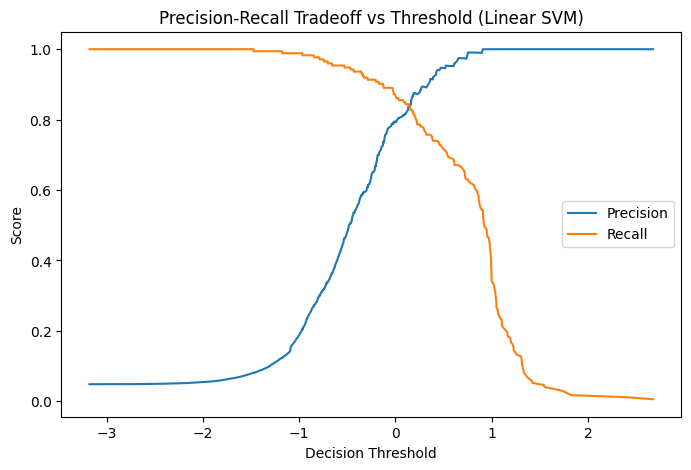

In [120]:
from sklearn.metrics import precision_recall_curve

svm_scores = svm.decision_function(X_test_tfidf)
precisions, recalls, thresholds = precision_recall_curve(y_test, svm_scores)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff vs Threshold (Linear SVM)')
plt.legend()
plt.show()

In [121]:
import numpy as np

target_recall = 0.95
idx = np.argmin(np.abs(recalls[:-1] - target_recall))
print(f"Threshold: {thresholds[idx]:.3f}, Precision: {precisions[idx]:.3f}, Recall: {recalls[idx]:.3f}")

Threshold: -0.530, Precision: 0.462, Recall: 0.948


In [122]:
target_recall = 0.90
idx = np.argmin(np.abs(recalls[:-1] - target_recall))
print(f"Threshold: {thresholds[idx]:.3f}, Precision: {precisions[idx]:.3f}, Recall: {recalls[idx]:.3f}")

Threshold: -0.173, Precision: 0.700, Recall: 0.902


In [123]:
final_threshold = -0.173
final_preds = (svm_scores >= final_threshold).astype(int)

print(classification_report(y_test, final_preds, target_names=['Legitimate', 'Fraudulent']))

              precision    recall  f1-score   support

  Legitimate       0.99      0.98      0.99      3403
  Fraudulent       0.70      0.90      0.79       173

    accuracy                           0.98      3576
   macro avg       0.85      0.94      0.89      3576
weighted avg       0.98      0.98      0.98      3576



Additionally after comparing the confusion/evaluation matrix.

Extracting the TF-IDF terms with the strongest influence on the Linear SVM's fraud predictions. Since decision_function is a weighted sum of TF-IDF features, the coefficient magnitude and sign tell us which words/phrases push a posting toward being flagged as fraudulent vs legitimate useful both as a sanity check on what the model actually learned, and as a potential explainability feature for the human-review system in the design.

In [124]:
feature_names = vectorizer.get_feature_names_out()
coefficients = svm.coef_[0]

top_fraud_idx = np.argsort(coefficients)[-20:][::-1]
top_legit_idx = np.argsort(coefficients)[:20]

In [125]:
print("Top terms pushing toward FRAUDULENT:")
for i in top_fraud_idx:
    print(f"  {feature_names[i]:30s} {coefficients[i]:.3f}")

print("\nTop terms pushing toward LEGITIMATE:")
for i in top_legit_idx:
    print(f"  {feature_names[i]:30s} {coefficients[i]:.3f}")

Top terms pushing toward FRAUDULENT:
  link                           3.194
  aptitude                       2.451
  offshore                       2.288
  high school                    1.965
  bottom                         1.831
  who are                        1.778
  working in                     1.771
  below                          1.740
  out of                         1.738
  word                           1.690
  american                       1.661
  please send                    1.643
  supplier                       1.634
  type                           1.623
  signing                        1.616
  money                          1.613
  fill                           1.601
  sites                          1.571
  excellence                     1.502
  compensation package           1.492

Top terms pushing toward LEGITIMATE:
  our                            -1.831
  an                             -1.792
  in all                         -1.671
  companies              

In [126]:
import joblib

joblib.dump(svm, 'svm_model.joblib')
joblib.dump(vectorizer, 'tfidf_vectorizer.joblib')

from google.colab import files
files.download('svm_model.joblib')
files.download('tfidf_vectorizer.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [127]:
print("LEGITIMATE EXAMPLE:\n", df[df['fraudulent']==0]['full_text'].iloc[0][:1000])
print("\n\nFRAUDULENT EXAMPLE:\n", df[df['fraudulent']==1]['full_text'].iloc[0][:1000])

LEGITIMATE EXAMPLE:
 Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly curated information about food and cooking. We attract the most talented home cooks and contributors in the country; we also publish well-known professionals like Mario Batali, Gwyneth Paltrow, and Danny Meyer. And we have partnerships with Whole Foods Market and Random House.Food52 has been named the best food website by the James Beard Foundation and IACP, and has been featured in the New York Times, NPR, Pando Daily, TechCrunch, and on the Today Show.We're located in Chelsea, in New York City. Food52, a fast-growing, James Beard Award-winning online food community and 

In [128]:
legit_example = df[df['fraudulent']==0]['full_text'].iloc[0]
fraud_example = df[df['fraudulent']==1]['full_text'].iloc[0]

print(legit_example)

Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly curated information about food and cooking. We attract the most talented home cooks and contributors in the country; we also publish well-known professionals like Mario Batali, Gwyneth Paltrow, and Danny Meyer. And we have partnerships with Whole Foods Market and Random House.Food52 has been named the best food website by the James Beard Foundation and IACP, and has been featured in the New York Times, NPR, Pando Daily, TechCrunch, and on the Today Show.We're located in Chelsea, in New York City. Food52, a fast-growing, James Beard Award-winning online food community and crowd-sourced and cur

In [129]:
print(fraud_example)

IC&E Technician                                                                                  Staffing &amp; Recruiting done right for the Oil &amp; Energy Industry!Represented candidates are automatically granted the following perks: Expert negotiations on your behalf, maximizing your compensation package and implimenting ongoing increases Significant signing bonus by Refined Resources (in addition to any potential signing bonuses our client companies offer)1 Year access to AnyPerk: significant corporate discounts on cell phones, event tickets, house cleaning and everything inbetween.  You'll save thousands on daily expenditures Professional Relocation Services for out of town candidates* All candidates are encouraged to participate in our Referral Bonus Program ranging anywhere from $500 - $1,000 for all successfully hired candidates... referred directly to the Refined Resources teamPlease submit referrals via online Referral FormThank you and we look forward to working with you s

In [130]:
import sklearn, joblib, numpy
print("scikit-learn:", sklearn.__version__)
print("joblib:", joblib.__version__)
print("numpy:", numpy.__version__)

scikit-learn: 1.6.1
joblib: 1.5.3
numpy: 2.0.2


In [131]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
